In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data = fetch_california_housing()

In [3]:
housing_df = pd.DataFrame(data=data.data, columns=data.feature_names)
housing_df['target'] = data.target

In [4]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
housing_df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [6]:
print(housing_df.corr())

              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
target      0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

            Latitude  Longitude    target  
MedInc     -0.079809  -0.015176  0.688075  
HouseAge    0.011173  -0.108197  0.105623  
AveRooms    0.106389  -0.027540  0.151948  
AveBedrms   0.069721   0.013344 -0.046701  
Populatio

In [7]:
print(housing_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [8]:
print(housing_df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [10]:
# model = LinearRegression().fit(housing_df.drop(columns=['target']), housing_df['target'])
#
# pipe = Pipeline([
#     ('scale', StandardScaler()),
#     ('model', KNeighborsRegressor(n_neighbors=1))
# ])

In [11]:
# pipe.fit(housing_df.drop(columns=['target']), housing_df['target'])

In [12]:
# pred = pipe.predict(housing_df.drop(columns=['target']))

In [13]:
# sns.scatterplot(x=pred, y=housing_df['target'])

In [14]:
param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance']
}

In [15]:
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', KNeighborsRegressor())
])

pipe.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()), ('model', KNeighborsRegressor())],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'model': KNeighborsRegressor(),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 5,
 'model__p': 2,
 'model__weights': 'uniform'}

In [16]:
gridCV = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5
)

In [17]:
gridCV.fit(housing_df.drop(columns=['target']), housing_df['target'])
pd.DataFrame(gridCV.cv_results_).sort_values('rank_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,param_model__weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.018130,0.000816,0.137254,0.014468,3,distance,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.432231,0.404428,0.549465,0.469931,0.537949,0.478801,0.057045,10
0,0.023935,0.009516,0.146794,0.014933,3,uniform,"{'model__n_neighbors': 3, 'model__weights': 'u...",0.435837,0.407158,0.548467,0.468958,0.537370,0.479558,0.055419,9
2,0.017774,0.000872,0.152901,0.014492,5,uniform,"{'model__n_neighbors': 5, 'model__weights': 'u...",0.478794,0.476008,0.576246,0.502598,0.572286,0.521186,0.044331,8
3,0.018305,0.001160,0.158457,0.017571,5,distance,"{'model__n_neighbors': 5, 'model__weights': 'd...",0.476861,0.474804,0.578780,0.504776,0.572744,0.521593,0.045519,7
4,0.017767,0.000691,0.157117,0.017360,7,uniform,"{'model__n_neighbors': 7, 'model__weights': 'u...",0.506359,0.497097,0.586361,0.508187,0.583880,0.536377,0.039984,6
5,0.017151,0.000642,0.161644,0.012959,7,distance,"{'model__n_neighbors': 7, 'model__weights': 'd...",0.504755,0.497586,0.589605,0.511913,0.584399,0.537652,0.040582,5
6,0.017639,0.000717,0.166886,0.012792,9,uniform,"{'model__n_neighbors': 9, 'model__weights': 'u...",0.522309,0.506643,0.591425,0.510436,0.593730,0.544909,0.039270,4
7,0.017863,0.000655,0.162996,0.014456,9,distance,"{'model__n_neighbors': 9, 'model__weights': 'd...",0.520497,0.508778,0.594806,0.514828,0.594188,0.546619,0.039268,3
8,0.017501,0.000569,0.173218,0.014855,11,uniform,"{'model__n_neighbors': 11, 'model__weights': '...",0.531398,0.511568,0.590933,0.513311,0.600215,0.549485,0.038379,2
9,0.017007,0.000471,0.171451,0.015101,11,distance,"{'model__n_neighbors': 11, 'model__weights': '...",0.529977,0.514756,0.594875,0.517772,0.600585,0.551593,0.038057,1


In [18]:
df = pd.read_csv('data/drawndata1.csv')
df.head()

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a


In [19]:
X = df[['x', 'y']].values
y = df['z'] == 'a'

<Axes: >

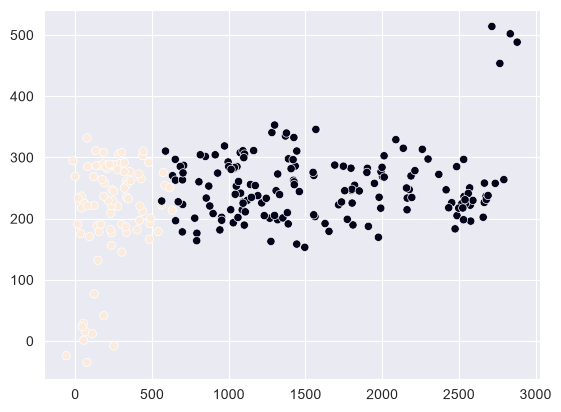

In [20]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], c=y)

In [21]:
X_new = StandardScaler().fit_transform(X)

<Axes: >

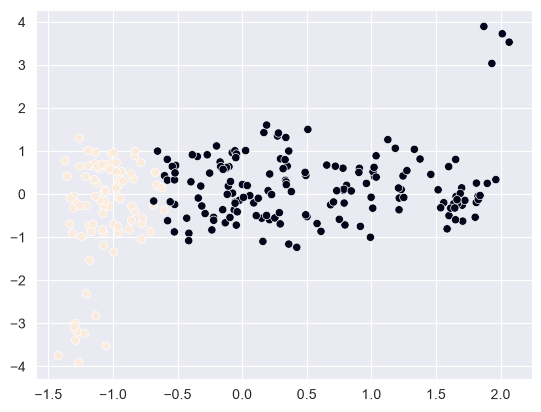

In [22]:
sns.scatterplot(x=X_new[:, 0], y=X_new[:, 1], c=y)

In [23]:
from sklearn.preprocessing import QuantileTransformer
X_new = QuantileTransformer().fit_transform(X)

C:\Users\user\Desktop\MlLibraries\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (252). n_quantiles is set to n_samples.
  warnings.warn(


<Axes: >

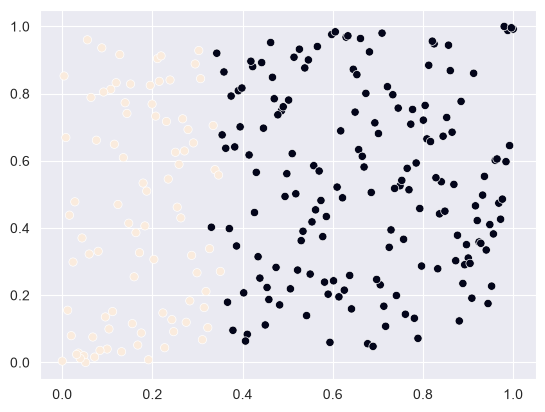

In [24]:
sns.scatterplot(x=X_new[:, 0], y=X_new[:, 1], c=y)

<Axes: >

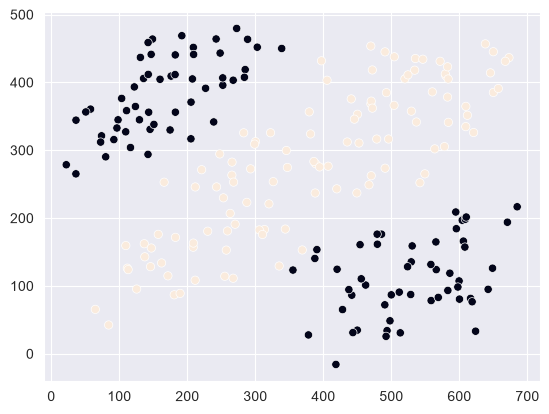

In [25]:
df2 = pd.read_csv('data/drawndata2.csv')
X = df2[['x', 'y']].values
y = df2['z'] == 'a'
sns.scatterplot(x = X[:, 0], y = X[:, 1], c=y)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

<Axes: >

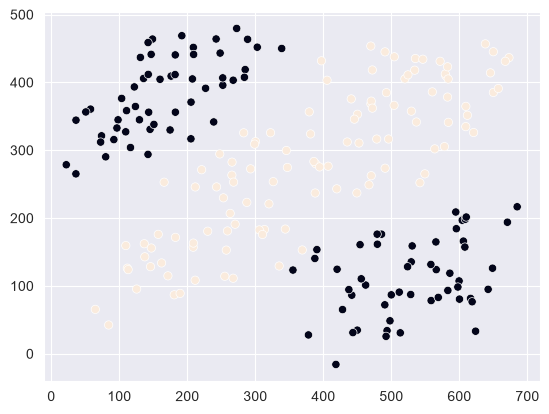

In [27]:
pipe2 = Pipeline([
    ('scale', PolynomialFeatures()),
    ('model', LogisticRegression())
])

pred = pipe2.fit(X, y).predict(X)
sns.scatterplot(x = X[:, 0], y = X[:, 1], c=pred)

In [28]:
arr = np.array(['low', 'low', 'medium', 'high', 'medium']).reshape(-1, 1)
arr

array([['low'],
       ['low'],
       ['medium'],
       ['high'],
       ['medium']], dtype='<U6')

In [29]:
from sklearn.preprocessing import OneHotEncoder

In [30]:
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit_transform(arr)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 3)>

In [31]:
enc

,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

In [32]:
enc.get_params()

{'categories': 'auto',
 'drop': None,
 'dtype': numpy.float64,
 'feature_name_combiner': 'concat',
 'handle_unknown': 'ignore',
 'max_categories': None,
 'min_frequency': None,
 'sparse_output': True}

In [33]:
enc.categories

'auto'

In [34]:
enc.transform([['zero']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (1, 3)>

In [35]:
df_credit = pd.read_csv('data/creditcard.csv')[:80000]
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [36]:
df_credit.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [37]:
df_credit['Class'].unique()

array([0, 1])

In [38]:
X = df_credit.drop(columns=['Time', 'Amount', 'Class'])
y = df_credit['Class']

In [39]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153


In [40]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [41]:
print(f"{X.shape} - {X.sum}")

(80000, 28) - <bound method DataFrame.sum of              V1        V2        V3        V4        V5        V6        V7  \
0     -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1      1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
...         ...       ...       ...       ...       ...       ...       ...   
79995  1.216664  0.249684  0.174210  0.510376 -0.179497 -0.560982 -0.021601   
79996 -0.690760  1.331928  0.913395  0.111679 -0.344744 -1.041187  0.340727   
79997 -2.287270  1.121568  1.163585  0.948471 -1.490482  1.046850 -0.699580   
79998 -1.350941  0.233411  0.950824  1.023505  0.415847 -0.505863  0.711381   
79999 -2.007004  0.736137  0.051847 -2.120136 -0.034212 -0.335378  1.294663   

      

In [42]:
model_credit = LogisticRegression(class_weight={0: 1, 1: 2})
model_credit.fit(X, y).predict(X).sum()

np.int64(172)

In [51]:
from sklearn.ensemble import IsolationForest
from collections import Counter

outlier_detector = IsolationForest().fit(X)
# Counter(outlier_detector.predict(X)) Counter({np.int64(1): 76749, np.int64(-1): 3251})
np.where(outlier_detector.predict(X) == -1, 1, 0)

array([0, 0, 0, ..., 0, 0, 0], shape=(80000,))

In [52]:
from sklearn.metrics import precision_score, recall_score, make_scorer

In [54]:
def outlier_precision(model, X, y):
    preds = model.predict(X)
    return precision_score(y, np.where(preds == -1, 1, 0))

In [55]:
def outlier_recall(model, X, y):
    preds = model.predict(X)
    return recall_score(y, np.where(preds == -1, 1, 0))

In [57]:
grid = GridSearchCV(
    estimator=IsolationForest(),
    param_grid={'contamination': np.linspace(0.001, 0.02, 10)},
    scoring={'precision': outlier_precision, 'recall': outlier_recall},
    refit='precision',
    cv=5,
    n_jobs=-1
)

grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",IsolationForest()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'contamination': array([0.001 ..., 0.02 ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'precision': <function out...002105B0F6840>, 'recall': <function out...002105B0F6DE0>}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbos

In [46]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,split3_test_recall,split4_test_recall,split5_test_recall,split6_test_recall,split7_test_recall,split8_test_recall,split9_test_recall,mean_test_recall,std_test_recall,rank_test_recall
0,0.538606,0.099239,0.020004,0.004302,"{0: 1, 1: 1.0}","{'class_weight': {0: 1, 1: 1.0}}",1.000000,0.463415,0.583333,1.000000,...,0.473684,0.35,0.85,0.90,0.45,0.00,0.40,0.552895,0.293874,30
1,0.503281,0.069104,0.013825,0.002127,"{0: 1, 1: 1.6551724137931034}","{'class_weight': {0: 1, 1: 1.6551724137931034}}",1.000000,0.441860,0.583333,1.000000,...,0.789474,0.35,0.85,0.95,0.50,0.25,0.55,0.639737,0.247661,29
2,0.457442,0.079256,0.016109,0.004920,"{0: 1, 1: 2.310344827586207}","{'class_weight': {0: 1, 1: 2.310344827586207}}",1.000000,0.431818,0.583333,1.000000,...,0.842105,0.40,0.85,0.95,0.50,0.25,0.60,0.655000,0.244257,28
3,0.452147,0.051930,0.016035,0.003625,"{0: 1, 1: 2.9655172413793105}","{'class_weight': {0: 1, 1: 2.9655172413793105}}",1.000000,0.431818,0.583333,1.000000,...,0.842105,0.40,0.85,0.95,0.50,0.25,0.70,0.686053,0.230605,27
4,0.251768,0.062938,0.009965,0.003113,"{0: 1, 1: 3.6206896551724137}","{'class_weight': {0: 1, 1: 3.6206896551724137}}",1.000000,0.431818,0.583333,1.000000,...,0.894737,0.45,0.85,0.95,0.50,0.30,0.70,0.717105,0.219513,26
5,0.185619,0.021861,0.007801,0.000740,"{0: 1, 1: 4.275862068965517}","{'class_weight': {0: 1, 1: 4.275862068965517}}",1.000000,0.431818,0.583333,1.000000,...,0.894737,0.45,0.85,0.95,0.50,0.35,0.70,0.732632,0.215999,25
6,0.190480,0.025090,0.007957,0.000642,"{0: 1, 1: 4.931034482758621}","{'class_weight': {0: 1, 1: 4.931034482758621}}",1.000000,0.431818,0.583333,1.000000,...,0.894737,0.45,0.85,0.95,0.55,0.35,0.80,0.747632,0.211427,24
7,0.186622,0.015004,0.007800,0.000713,"{0: 1, 1: 5.586206896551724}","{'class_weight': {0: 1, 1: 5.586206896551724}}",1.000000,0.431818,0.583333,1.000000,...,0.947368,0.50,0.85,1.00,0.60,0.35,0.80,0.767895,0.209612,23
8,0.180758,0.012427,0.007726,0.000845,"{0: 1, 1: 6.241379310344827}","{'class_weight': {0: 1, 1: 6.241379310344827}}",1.000000,0.422222,0.583333,0.947368,...,0.947368,0.50,0.85,1.00,0.70,0.45,0.80,0.787895,0.183907,22
9,0.186103,0.013818,0.008055,0.000705,"{0: 1, 1: 6.896551724137931}","{'class_weight': {0: 1, 1: 6.896551724137931}}",0.944444,0.422222,0.583333,0.947368,...,0.947368,0.50,0.85,1.00,0.70,0.50,0.80,0.792895,0.175122,21


In [47]:
lr = LogisticRegression()
??lr.score

In [48]:
from sklearn.metrics import precision_score, recall_score

In [49]:
precision_score(y, grid.predict(X))

0.7878787878787878

In [50]:
recall_score(y, grid.predict(X))

0.6632653061224489